In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [2]:
# Step 2: Load File
file = "sum1.csv"
data = pd.read_csv(file)


In [3]:
#Preprocessing
data.dropna(inplace=True)

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

#Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [4]:
#Step 3: Data Preprocessing
print("Dataset:\n", data)

Dataset:
    Age  Glucose
0   43       99
1   21       65
2   25       79
3   42       75
4   57       87
5   59       81


In [5]:
print(X_train.dtypes)
print(y_train.dtypes)

Age    int64
dtype: object
int64


In [6]:
#Remove extra spaces in column names
data.columns = data.columns.str.strip()

In [7]:
 #Check missing values
print("\nMissing values:\n", data.isnull().sum())


Missing values:
 Age        0
Glucose    0
dtype: int64


In [8]:
#Drop missing values
data = data.dropna()

In [9]:
#Convert to numeric (safety step)
data['Age'] = pd.to_numeric(data['Age'], errors='coerce')
data['Glucose'] = pd.to_numeric(data['Glucose'], errors='coerce')


In [10]:
#Step 4: Define Features and Target
X = data[['Age']] #Indepenedent variable
y = data['Glucose'] #Depenedent variable

In [11]:
#Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
#Step 6: Create and Train Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
#Step 7: Get Slope and Intercept
slope = model.coef_[0]
intercept = model.intercept_

print("\nSlope (b):", slope)
print("Intercept (a):", intercept)

#Regression Equation
print(f"\nRegression Equation: Y = {intercept:.2f} + {slope:.2f}X")


Slope (b): 0.5082454717491214
Intercept (a): 54.25601513922682

Regression Equation: Y = 54.26 + 0.51X


In [14]:
#Step 8: Prediction
Age = float(input("\nEnter Area to predict price:"))
predicted_Glucose = model.predict([[Glucose]])

print(f"Predicted Price for {area} sq.ft = {predicted_Glucose[0]:.2f}")


Enter Area to predict price: 20


Predicted Price for 20.0 sq.ft = 64.42


C:\Users\uday2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


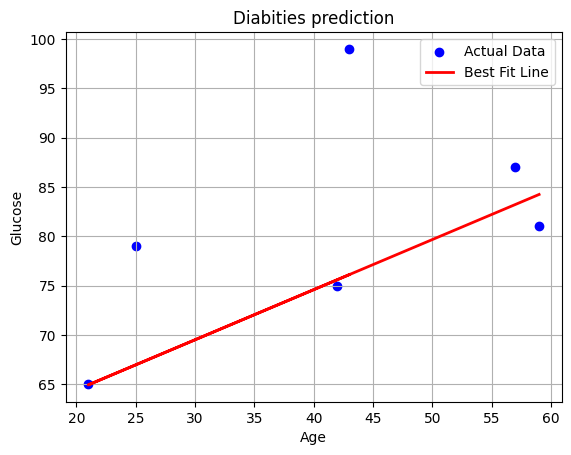

In [16]:
#Step 9: Best Fit Line Graph
plt.scatter(X,y,color='blue',label="Actual Data")
plt.plot(X, model.predict(X), color='red', linewidth=2, label="Best Fit Line")

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Diabities prediction")
plt.legend()
plt.grid(True)
plt.show()